In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [74]:
#First 5 Record
display(df.head(5))

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [75]:
#Number of Rows and Columns
print("Number of Rows", df.shape[0])
print("Number of Columns", df.shape[1])

Number of Rows 7043
Number of Columns 21


In [76]:
#Data Types of All Columns
print("Data Types: ", df.dtypes)

Data Types:  customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [77]:
#Number of Missing Values in Each Column
print("Number of Missing Values", df.isnull().sum())

Number of Missing Values customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [78]:
#Convert TotalCharges into a Suitable Numerical Datatype
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Missing Values after converting TotalCharges:",
      df['TotalCharges'].isnull().sum())

Missing Values after converting TotalCharges: 11


In [79]:
#Handle Missing Values after convert TotalCharges Column
df['TotalCharges'] = df['TotalCharges'].fillna(
    df['TotalCharges'].median()
)

print("Missing values after handling: ", df.isnull().sum())

Missing values after handling:  customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [80]:
#Remove CustomerID
df = df.drop('customerID', axis=1)

In [81]:
#Encode the target variables churn
df['Churn'] = df['Churn'].map({
    "No": 0,
    "Yes": 1
})

In [82]:
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [84]:
#Encode Categorical Variables
x = df.drop('Churn', axis=1)
y = df['Churn']

x = pd.get_dummies(
    x,
    drop_first=True
)

print("Shape after encoding: ")
print(x.shape)

print("Encoded columns: ")
print(x.columns)

Shape after encoding: 
(7043, 30)
Encoded columns: 
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


In [91]:
#Churn Percentage
churn_percentage = df['Churn'].mean()*100

print(f"{churn_percentage:.2f}%")

26.54%


In [98]:
avg_monthly_Charges = df.groupby('Churn')['MonthlyCharges'].mean()
print(avg_monthly_Charges)

Churn
0    61.265124
1    74.441332
Name: MonthlyCharges, dtype: float64


In [99]:
avg_tenure = df.groupby('Churn')['tenure'].mean()
print(avg_tenure)

Churn
0    37.569965
1    17.979133
Name: tenure, dtype: float64


In [100]:
from sklearn.model_selection import train_test_split

In [105]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [107]:
from sklearn.preprocessing import StandardScaler

In [108]:
scaler = StandardScaler()

In [110]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [112]:
from sklearn.linear_model import LogisticRegression

In [113]:
logistic_model = LogisticRegression(
    random_state = 42,
    max_iter = 1000
)

In [114]:
logistic_model.fit(
    x_train,
    y_train

)

LogisticRegression(max_iter=1000, random_state=42)

In [116]:
y_predict = logistic_model.predict(x_test)

In [117]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [162]:
lr_Accuracy = accuracy_score(y_test, y_predict)
print(f"Accuracy: {lr_Accuracy:.4f}")
lr_Precision = precision_score(y_test, y_predict)
print(f"Precision: {lr_Precision:.4f}")
lr_Recall = recall_score(y_test, y_predict)
print(f"Recall: {lr_Recall:.4f}")
lr_F1_Score = f1_score(y_test, y_predict)
print(f"F1 Score: {lr_F1_Score:.4f}")

Accuracy: 0.8070
Precision: 0.6584
Recall: 0.5668
F1 Score: 0.6092


In [122]:
from sklearn.metrics import confusion_matrix, classification_report

In [125]:
cm_lr = confusion_matrix(y_test, y_predict)
print(cm_lr)

[[925 110]
 [162 212]]


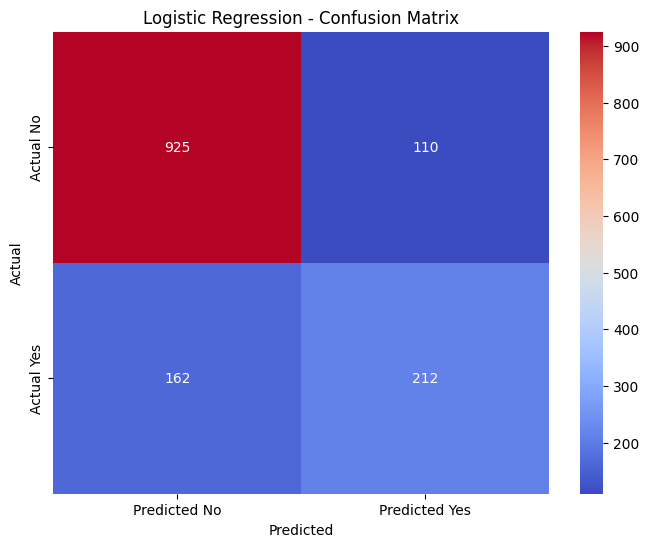

In [128]:
plt.figure(figsize=(8,6))

sns.heatmap(cm_lr,
            annot=True,
            fmt='d',
            cmap='coolwarm',
            xticklabels=["Predicted No", "Predicted Yes"],
            yticklabels = ["Actual No", "Actual Yes"])
plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [130]:
print(classification_report(
    y_test,
    y_predict,
    target_names = ["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [131]:
coefficients = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": logistic_model.coef_[0]
})

coefficients["Absolute_Coefficient"]=(
    coefficients["Coefficient"].abs()
)

top_5_lr = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
).head(5)

print("Top 5 Features Influencing Churn: ")
display(top_5_lr)

Top 5 Features Influencing Churn: 


,Feature,Coefficient,Absolute_Coefficient
1,tenure,-1.219639,1.219639
2,MonthlyCharges,-0.921369,0.921369
10,InternetService_Fiber optic,0.778760,0.778760
25,Contract_Two year,-0.588975,0.588975
3,TotalCharges,0.497246,0.497246


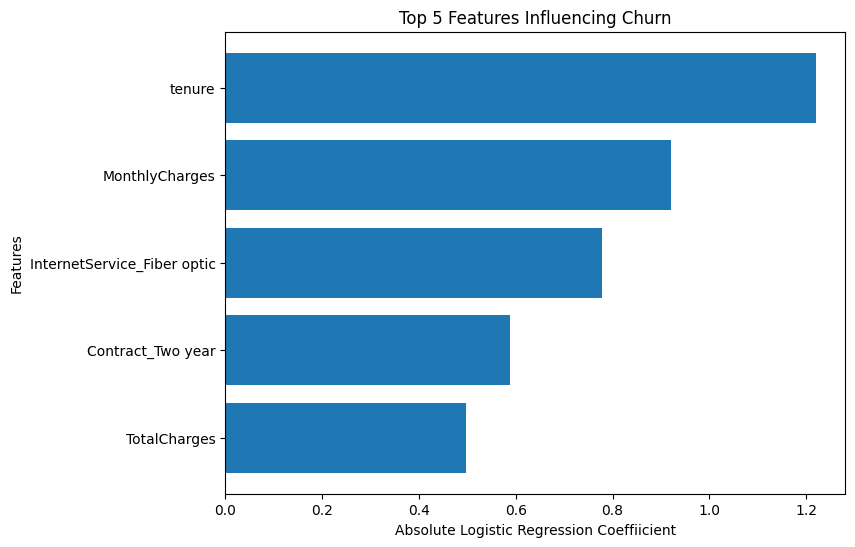

In [132]:
plt.figure(figsize=(8,6))

plt.barh(
    top_5_lr["Feature"],
    top_5_lr['Absolute_Coefficient']
)

plt.xlabel("Absolute Logistic Regression Coeffiicient")
plt.ylabel("Features")
plt.title("Top 5 Features Influencing Churn")

plt.gca().invert_yaxis()
plt.show()

In [133]:
from sklearn.ensemble import RandomForestClassifier

In [134]:
random_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

In [135]:
random_model.fit(
    x_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [136]:
y_predict_rf = random_model.predict(x_test)

In [163]:
rf_Accuracy = accuracy_score(y_test, y_predict_rf)
print(f"Accuracy: {rf_Accuracy:.4f}")
rf_Precision = precision_score(y_test, y_predict_rf)
print(f"Precision: {rf_Precision:.4f}")
rf_Recall = recall_score(y_test, y_predict_rf)
print(f"Recall: {rf_Recall:.4f}")
rf_F1_Score = f1_score(y_test, y_predict_rf)
print(f"F1 Score: {rf_F1_Score:.4f}")

Accuracy: 0.7857
Precision: 0.6216
Recall: 0.4920
F1 Score: 0.5493


In [144]:
cm_rf = confusion_matrix(
    y_test,
    y_predict_rf
)

print(cm_rf)

[[923 112]
 [190 184]]


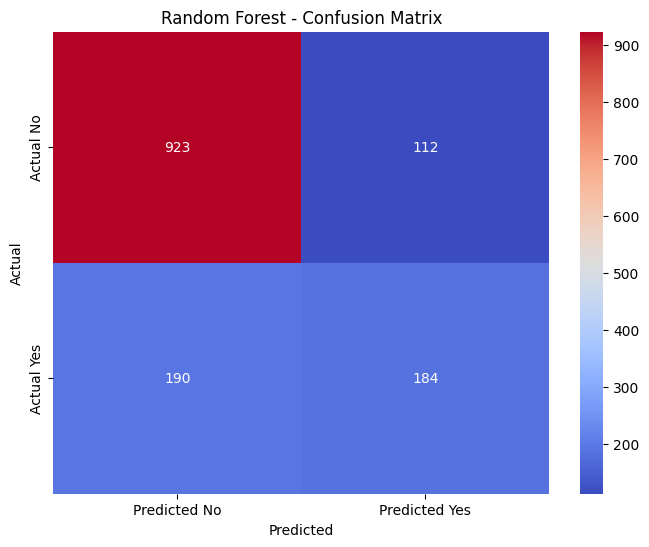

In [145]:
plt.figure(figsize=(8,6))

sns.heatmap(cm_rf,
            annot=True,
            fmt = 'd',
            cmap = 'coolwarm',
            xticklabels = ["Predicted No", "Predicted Yes"],
            yticklabels = ["Actual No", "Actual Yes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [147]:
print(classification_report(
    y_test,
    y_predict_rf,
    target_names = ["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



In [149]:
feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": random_model.feature_importances_
})

top_10_rf = feature_importance.sort_values(
    "Importance",
    ascending=False
).head(10)

display(top_10_rf)

,Feature,Importance
3,TotalCharges,0.192096
1,tenure,0.174733
2,MonthlyCharges,0.168413
28,PaymentMethod_Electronic check,0.038771
10,InternetService_Fiber optic,0.038641
25,Contract_Two year,0.030176
4,gender_Male,0.028321
13,OnlineSecurity_Yes,0.028191
26,PaperlessBilling_Yes,0.025617
5,Partner_Yes,0.023326


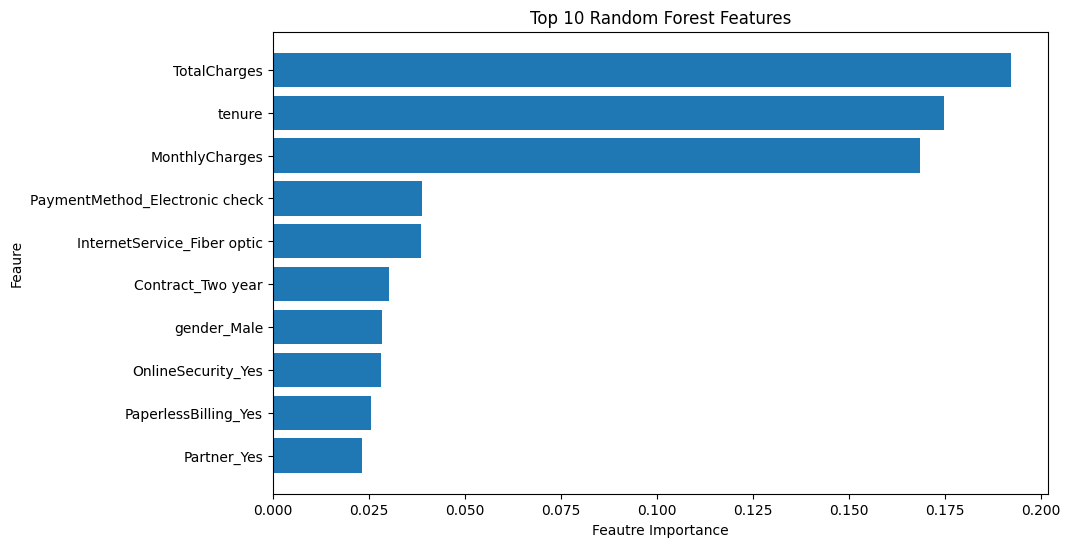

In [154]:
plt.figure(figsize=(10,6))

plt.barh(
    top_10_rf["Feature"],
    top_10_rf["Importance"]
)
plt.xlabel("Feautre Importance")
plt.ylabel("Feaure")
plt.title("Top 10 Random Forest Features")
plt.gca().invert_yaxis()
plt.show()

In [166]:
comparision = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy":[
        lr_Accuracy,
        rf_Accuracy
    ],
    "Precision":[
        lr_Precision,
        rf_Precision
    ],
    "Recall":[
        lr_Recall,
        rf_Recall
    ],
    "F1 Score":[
        lr_F1_Score,
        rf_F1_Score
    ]

})

comparision = (comparision).round(4)

display(comparision)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8070,0.6584,0.5668,0.6092
1,Random Forest,0.7857,0.6216,0.4920,0.5493


In [170]:
print(f"Logistic Regression Churn Recall: {lr_Recall:.4f}")
print(f"Random Forest Churn Recall: {rf_Recall:.4f}")

if lr_Recall > rf_Recall:
  print("Logistic Regression has higher recall for Churn = Yes.")
elif rf_Recall > lr_Recall:
  print("Random Forest has higher recall for Churn = Yes.")
else:
  print("Both models have the same recall for churn = Yes")

Logistic Regression Churn Recall: 0.5668
Random Forest Churn Recall: 0.4920
Logistic Regression has higher recall for Churn = Yes.


In [175]:
cm_rf = confusion_matrix(y_test,
                         y_predict_rf
                         )
print(cm_rf)

[[923 112]
 [190 184]]


In [171]:
tp  = cm_rf[1, 1]
print(f"True Positive: {tp}")

True Positive: 184


In [172]:
fp = cm_rf[0, 1]
print(f"False Positive: {fp}")

False Positive: 112


In [173]:
fn = cm_rf[1, 0]
print(f"False Negative: {fn}")

False Negative: 190


In [174]:
tn = cm_rf[0, 0]
print(f"True Negative: {tn}")

True Negative: 923


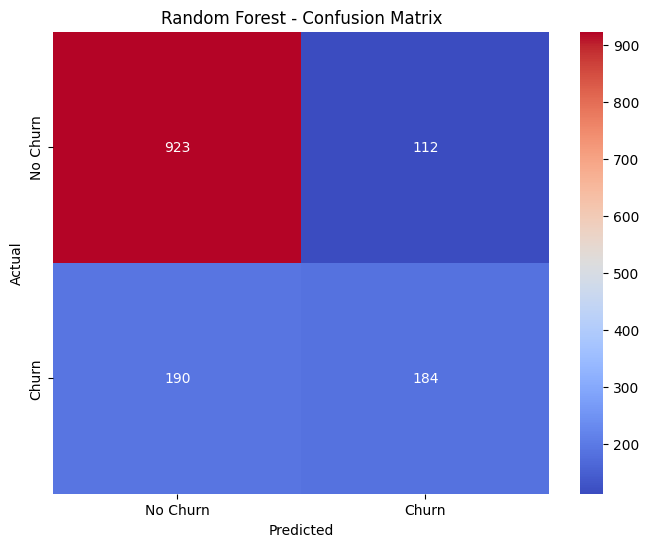

In [176]:
plt.figure(figsize=(8,6))

sns.heatmap(cm_rf,
            annot=True,
            fmt = 'd',
            cmap = 'coolwarm',
            xticklabels = ["No Churn", "Churn"],
            yticklabels = ["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [177]:
top_3_rf = top_10_rf.head(3)
print("Top 3 Features Influencing Churn: ")
display(top_3_rf)

Top 3 Features Influencing Churn: 


,Feature,Importance
3,TotalCharges,0.192096
1,tenure,0.174733
2,MonthlyCharges,0.168413


In [ ]:
### Interpretation of Top 3 Random Forest Features

#The top three features are the customer characteristics with the highest feature
# importance in the Random Forest model. These features contributed most to the
# model's ability to distinguish between churned and non-churned customers.

#A higher feature importance means that the feature was more useful for the
#Random Forest's predictions. However, feature importance does not imply that
#the feature directly causes customer churn.